<a href="https://www.kaggle.com/code/flixrojas/air-quality-data-filtering?scriptVersionId=311393451" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
from google.cloud import bigquery

client = bigquery.Client()
dataset_ref = client.dataset("epa_historical_air_quality", project="bigquery-public-data")
dataset = client.get_dataset(dataset_ref)

tables = list(client.list_tables(dataset))

print("Tables in the EPA dataset:")
for table in tables:
    print(table.table_id)

Using Kaggle's public dataset BigQuery integration.
Tables in the EPA dataset:
air_quality_annual_summary
co_daily_summary
co_hourly_summary
hap_daily_summary
hap_hourly_summary
lead_daily_summary
no2_daily_summary
no2_hourly_summary
nonoxnoy_daily_summary
nonoxnoy_hourly_summary
o3_daily_summary
o3_hourly_summary
pm10_daily_summary
pm10_hourly_summary
pm25_frm_daily_summary
pm25_frm_hourly_summary
pm25_nonfrm_daily_summary
pm25_nonfrm_hourly_summary
pm25_speciation_daily_summary
pm25_speciation_hourly_summary
pressure_daily_summary
pressure_hourly_summary
rh_and_dp_daily_summary
rh_and_dp_hourly_summary
so2_daily_summary
so2_hourly_summary
temperature_daily_summary
temperature_hourly_summary
voc_daily_summary
voc_hourly_summary
wind_daily_summary
wind_hourly_summary


In [3]:
table_ref = dataset_ref.table("air_quality_annual_summary")
table = client.get_table(table_ref)

for schema_field in table.schema:
    print(f"{schema_field.name} - {schema_field.field_type}")

state_code - STRING
county_code - STRING
site_num - STRING
parameter_code - INTEGER
poc - INTEGER
latitude - FLOAT
longitude - FLOAT
datum - STRING
parameter_name - STRING
sample_duration - STRING
pollutant_standard - STRING
metric_used - STRING
method_name - STRING
year - INTEGER
units_of_measure - STRING
event_type - STRING
observation_count - INTEGER
observation_percent - FLOAT
completeness_indicator - STRING
valid_day_count - INTEGER
required_day_count - INTEGER
exceptional_data_count - INTEGER
null_data_count - INTEGER
primary_exceedance_count - INTEGER
secondary_exceedance_count - INTEGER
certification_indicator - STRING
num_obs_below_mdl - INTEGER
arithmetic_mean - FLOAT
arithmetic_standard_dev - FLOAT
first_max_value - FLOAT
first_max_datetime - TIMESTAMP
second_max_value - FLOAT
second_max_datetime - TIMESTAMP
third_max_value - FLOAT
third_max_datetime - TIMESTAMP
fourth_max_value - FLOAT
fourth_max_datetime - TIMESTAMP
first_max_non_overlapping_value - FLOAT
first_no_max_date

In [7]:
# Extracting the arithmetic mean of particulates below 2.5
# these particulates stem from vehicle and building emissions
# that can be generated by burning, chemical reactions, dust storms
# they can also be secondarily generated in the atmosphere through chemical reactions

query = """
SELECT 
    date_local, 
    arithmetic_mean as pm25
FROM 
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary`
WHERE 
    state_name = 'California' 
    AND county_name = 'Los Angeles'
    AND date_local >= '2018-01-01' AND date_local <= '2025-12-31'
ORDER BY 
    date_local ASC
"""

query_job = client.query(query)
 
df = query_job.to_dataframe()

display(df.head())

/usr/local/lib/python3.12/dist-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,date_local,pm25
0,2018-01-01,111.008333
1,2018-01-01,16.400000
2,2018-01-01,77.300000
3,2018-01-01,16.404167
4,2018-01-01,79.600000


I'm changing the format to pandas datetime just to make sure it is handled properly

I will also be printing the dataframe info to make sure I do not have to deal with empty or null values since it is a time series

In [8]:
# reformatting the data and averaging county data measurements
df['date_local'] = pd.to_datetime(df['date_local'])

# date is now the index so we can query using a specified datetime
df.set_index('date_local', inplace=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 20356 entries, 2018-01-01 to 2025-05-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pm25    20356 non-null  float64
dtypes: float64(1)
memory usage: 318.1 KB
None


## Preprocessing
Since the data is a time series, we need to ensure that it is:
- Contiguous
- Sorted
- Free of missing values (done)

I will proceed to visualize the dataset to look for 
- Seasonality (repeating patterns)
- Trend (arrangement of datpoints following a pattern)

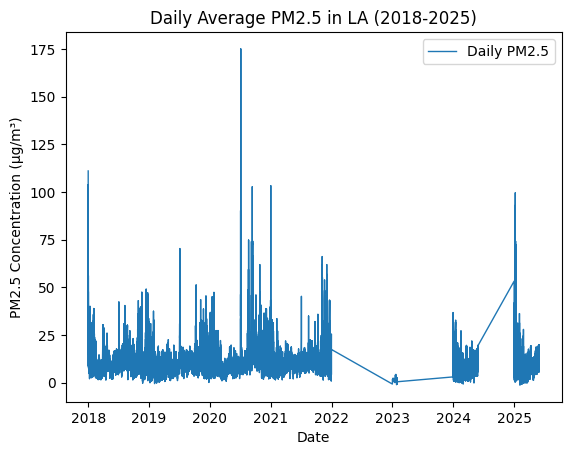

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.plot(df.index, df['pm25'], label='Daily PM2.5', linewidth=1)
plt.title('Daily Average PM2.5 in LA (2018-2025)')
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.legend()
plt.show()

That is how the overall data looks but there are two problems: 
- sample is too large, so I will reduce it to a random year to see if there might be seasonal changes (like summer wildfires)
- Datapoints from 2022 - 2023, 2023 - 2024 and 2024-2025 look suspiciously wrong 

First I will plot two years that don't look suspicious to see if there is seasonality or trend within them. I'll define a function to plot a range for this PDA.

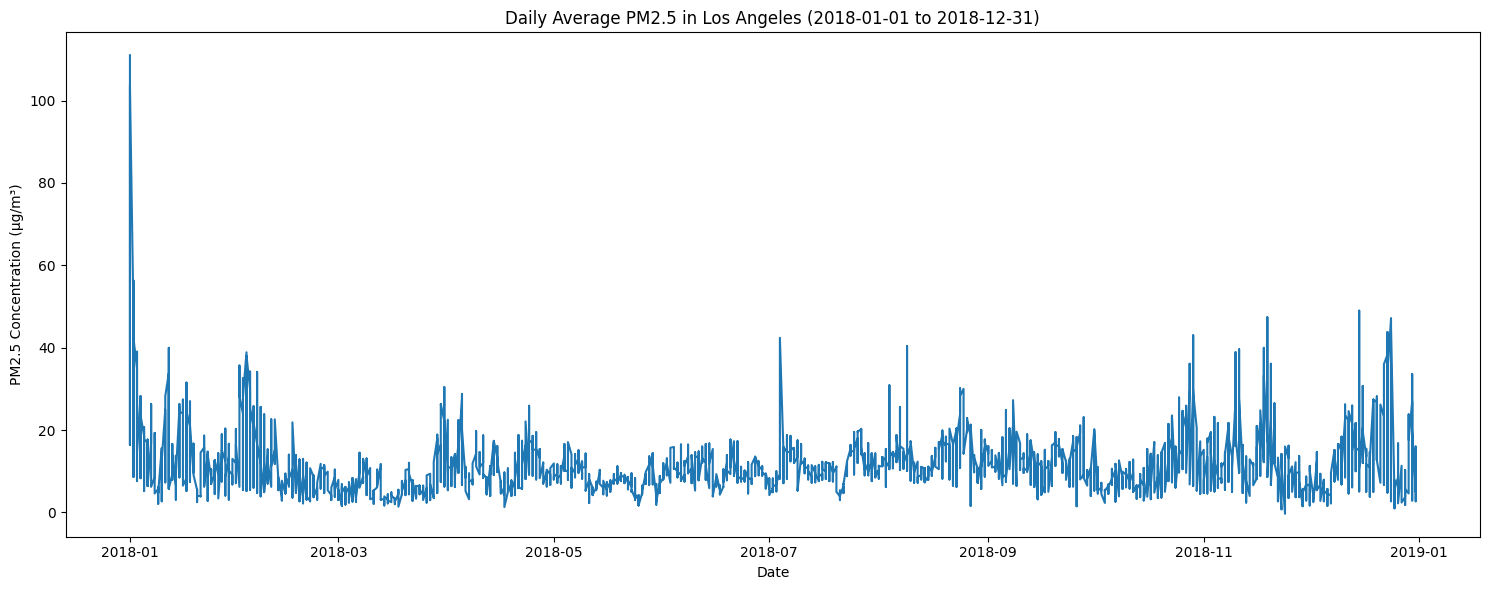

In [10]:
def plot_date_range(df, start_date, end_date, column='pm25'):
    date_range_subset = df.loc[pd.to_datetime(start_date):pd.to_datetime(end_date)]
    
    plt.figure(figsize=(15, 6))
    plt.plot(date_range_subset.index, date_range_subset[column], linewidth=1.5)
    
    plt.title(f'Daily Average PM2.5 in Los Angeles ({start_date} to {end_date})')
    plt.xlabel('Date')
    plt.ylabel('PM2.5 Concentration (µg/m³)')
    plt.tight_layout()
    plt.show()

plot_date_range(df, '2018-01-01','2018-12-31')

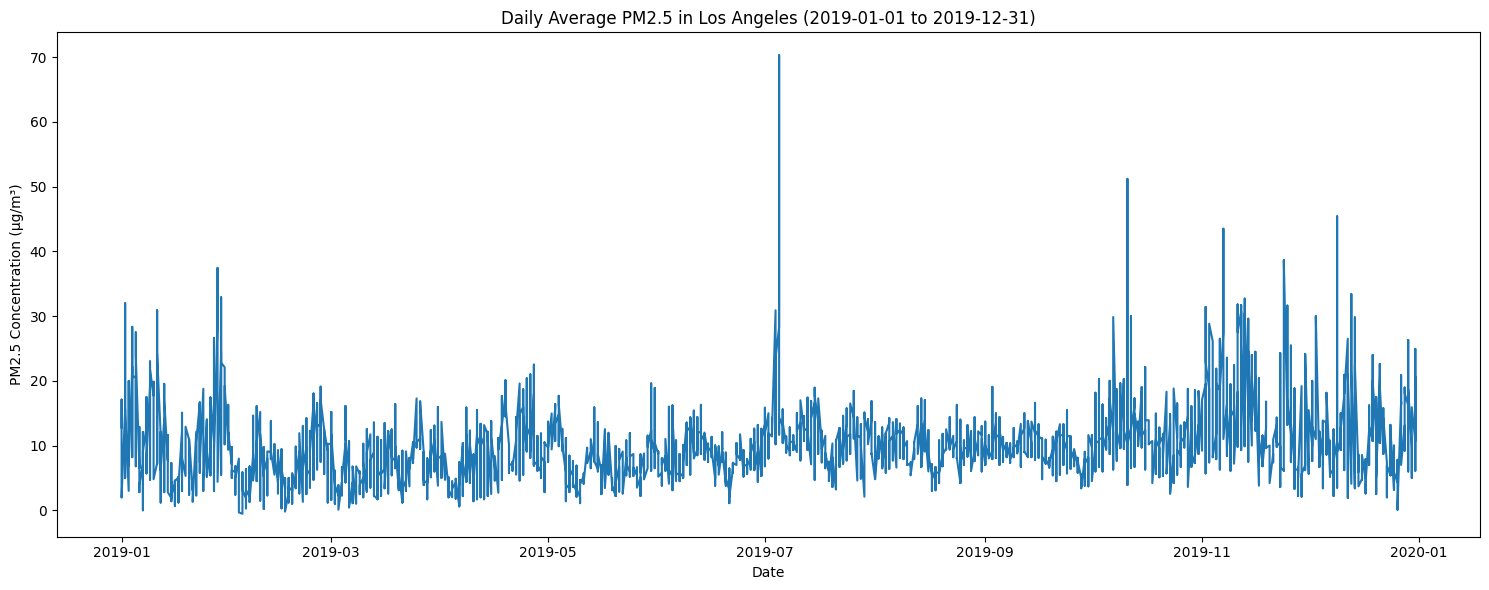

In [11]:
plot_date_range(df, '2019-01-01','2019-12-31')

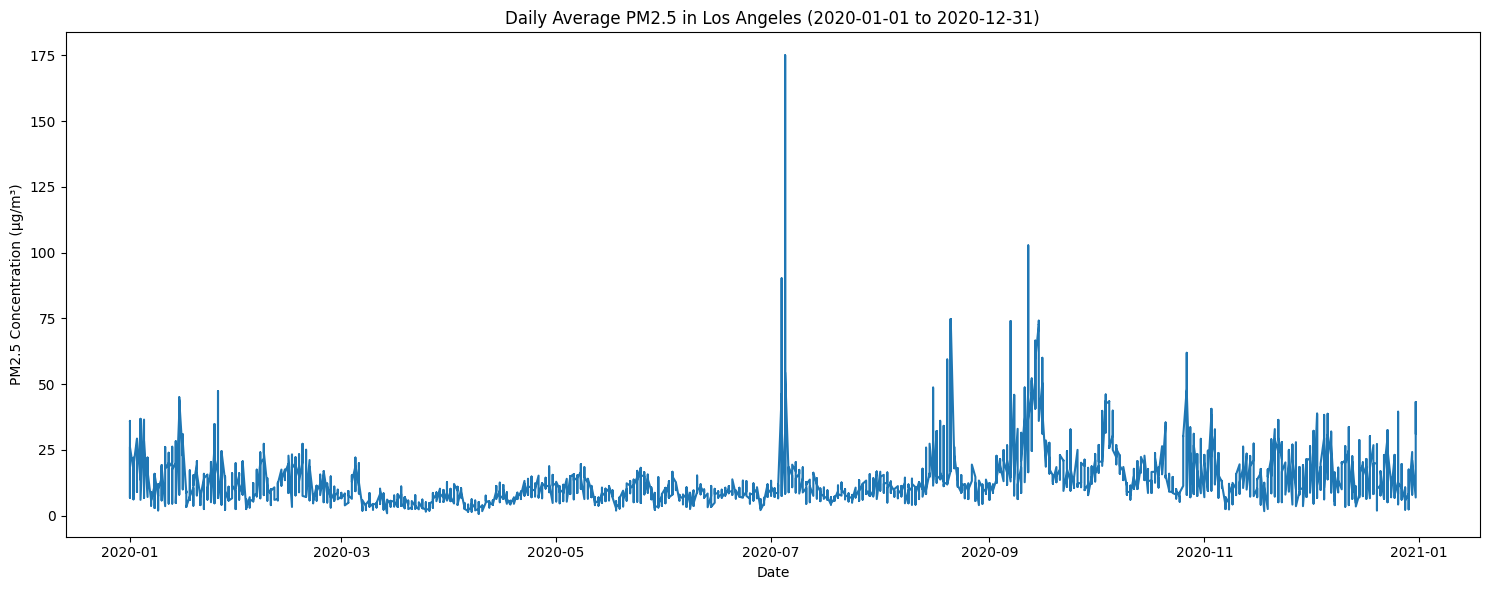

In [12]:
plot_date_range(df, '2020-01-01','2020-12-31')

There seems to be some seasonality on the last months and the beginning months (probably due to increased electric consumption in winter) and an insane peak in July (fireworks due to July 4th)

I will now make boxplots for the seasons to make the visualization clearer

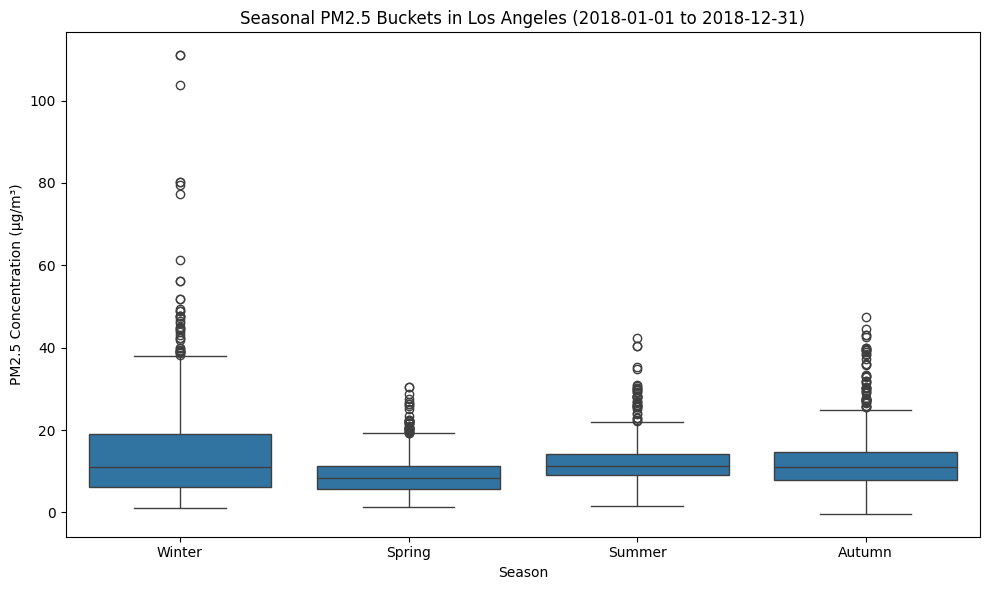

In [13]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

def plot_seasonal_buckets(df, start_date, end_date, column='pm25'):
    subset = df.loc[start_date:end_date].copy()
    
    subset['season'] = subset.index.month.map(get_season)
    plt.figure(figsize=(10, 6))
    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
    
    sns.boxplot(data=subset, x='season', y=column, order=season_order)
    
    plt.title(f'Seasonal PM2.5 Buckets in Los Angeles ({start_date} to {end_date})')
    plt.xlabel('Season')
    plt.ylabel('PM2.5 Concentration (µg/m³)')
    plt.tight_layout()
    plt.show()

plot_seasonal_buckets(df, '2018-01-01', '2018-12-31')

/tmp/ipykernel_56/3159412299.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


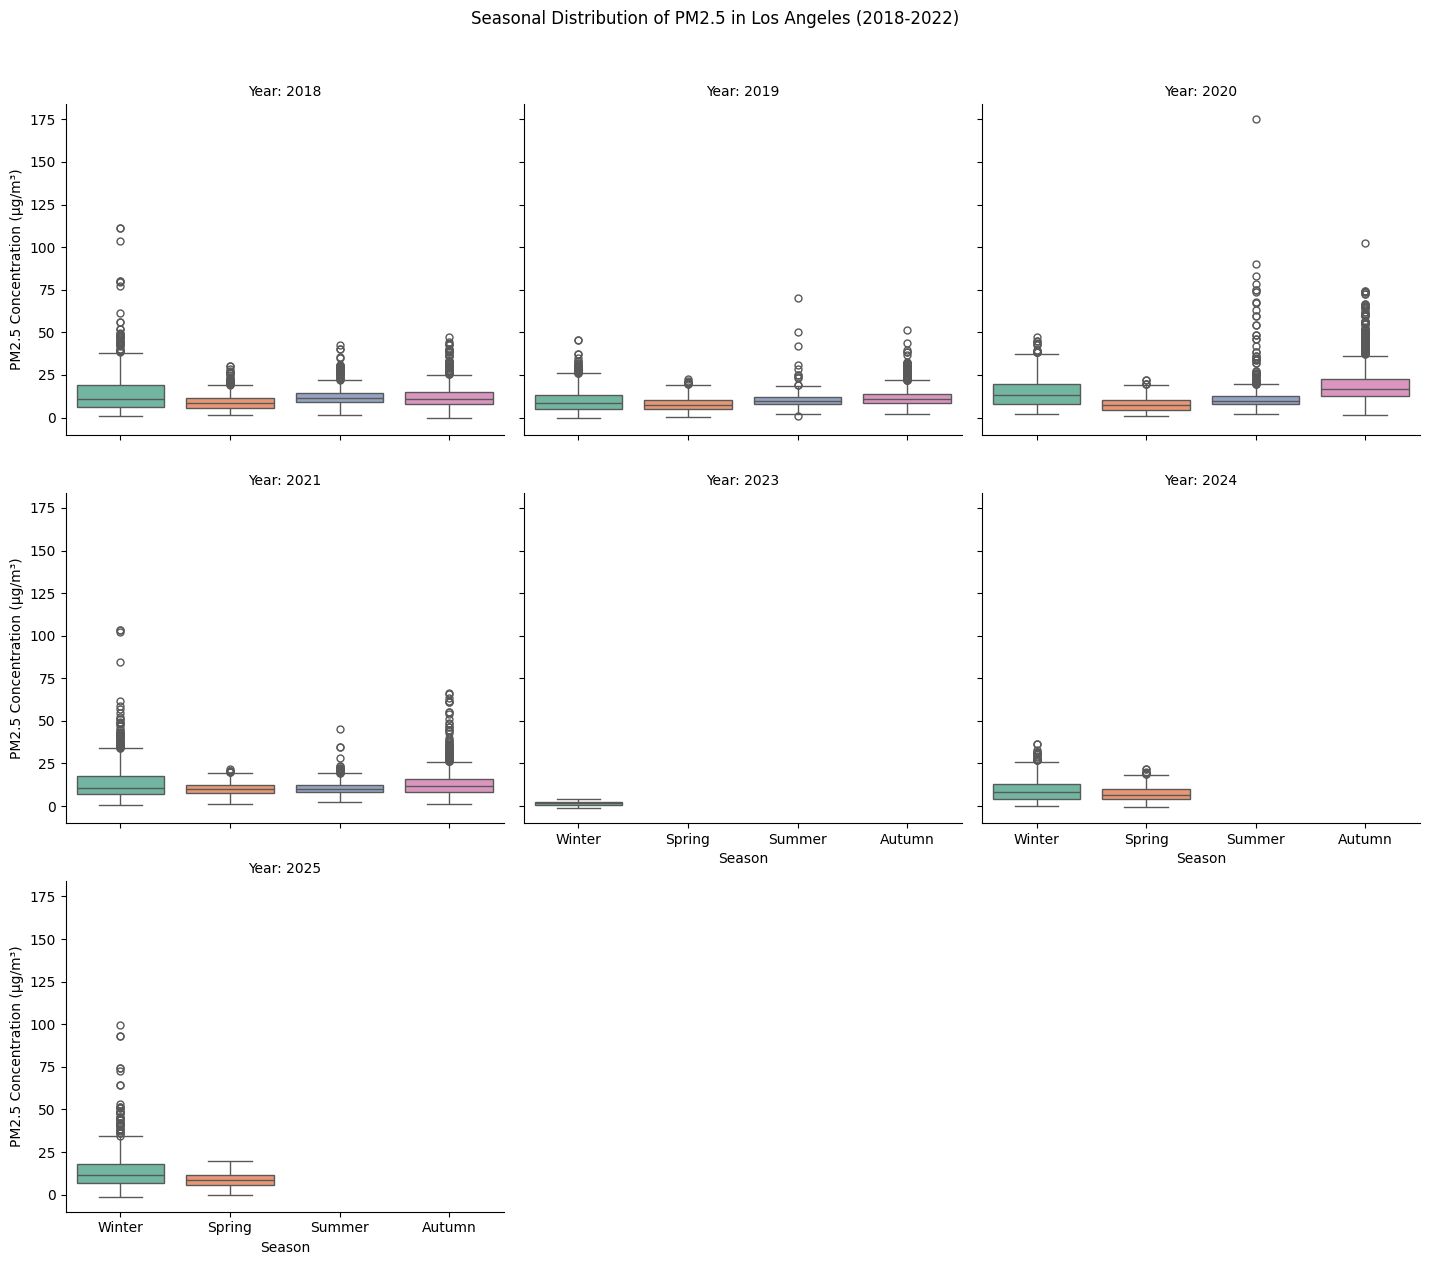

In [14]:
# the following code was generated by Gemini 3.1 pro
# why? i needed a complex graph and I am not used to the seaborn package
# it is also just for EDA

# 1. Create a copy and extract the necessary categorical columns
df_subplots = df.copy()
df_subplots['year'] = df_subplots.index.year
df_subplots['season'] = df_subplots.index.month.map(get_season)

# 2. Define the logical order for the x-axis
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

# 3. Use catplot to generate the subplots
# 'col="year"' tells Seaborn to make a new subplot for each unique year
# 'col_wrap=3' limits the grid to 3 subplots per row before wrapping to the next line
g = sns.catplot(
    data=df_subplots, 
    x='season', 
    y='pm25', 
    col='year', 
    col_wrap=3, 
    kind='box', 
    order=season_order,
    height=4, 
    aspect=1.2,
    palette='Set2'
)

# 4. Format the titles and labels
g.set_axis_labels("Season", "PM2.5 Concentration (µg/m³)")
g.set_titles("Year: {col_name}")

# Add a main title to the entire figure (y=1.05 pushes it slightly above the subplots)
g.fig.suptitle("Seasonal Distribution of PM2.5 in Los Angeles (2018-2022)", y=1.05)

plt.show()

Years 2022 and onwards look incomplete, so I will only use the data from 2018-2021.

Also there is a clear indication that Winter has the largest variation and ranges for PM 2.5, so this set does possess seasonality (as well as in Autumn)!

## Data split
Since the data from 2022 seems to be incomplete, I will split the data using the classic 80 - 20 split from 2018 to 2021

In [15]:
filtered_data = df.loc['2018-01-01':'2021-12-31']

training_fraction = 0.8

# index where the split happens
# int casting because it's supposed to be an idx
split_index = int(training_fraction * len(filtered_data))

train_data = filtered_data.iloc[:split_index]
test_data = filtered_data.iloc[split_index:]

Finally we rescale the data to go from 0.0 to 1.0 for training

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data[['pm25']])
test_scaled = scaler.transform(test_data[['pm25']])

## Second approximation
My goal is to determine PM2.5 presence in the air using the overall data from 2018-2021, due to some data gaps in 2023
I will do the same query but merging related data to wind and temperature as potentially predictive

I'll do a test query to see how many datapoints we are dealing with

In [21]:
test_query = """
SELECT
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.date_local,
    pm.arithmetic_mean AS pm25_level,
    t.arithmetic_mean AS temperature,
    w.arithmetic_mean AS wind_speed
FROM
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary` AS pm
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.temperature_daily_summary` AS t
    ON pm.state_code = t.state_code
    AND pm.county_code = t.county_code
    AND pm.site_num = t.site_num
    AND pm.date_local = t.date_local
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.wind_daily_summary` AS w
    ON pm.state_code = w.state_code
    AND pm.county_code = w.county_code
    AND pm.site_num = w.site_num
    AND pm.date_local = w.date_local
WHERE
    -- only 2020
    pm.date_local >= '2020-01-01' 
    AND pm.date_local <= '2020-12-31'
    AND pm.state_code = '06' -- California
ORDER BY
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.date_local;
"""

query_job = client.query(test_query)
 
df_large_test = query_job.to_dataframe()

display(df_large_test.head())

/usr/local/lib/python3.12/dist-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,state_code,county_code,site_num,date_local,pm25_level,temperature,wind_speed
0,06,007,0008,2020-01-01,23.500000,48.595833,0.862500
1,06,007,0008,2020-01-01,23.500000,48.595833,174.083333
2,06,007,0008,2020-01-01,23.500000,48.595833,0.862500
3,06,007,0008,2020-01-01,23.500000,48.595833,174.083333
4,06,007,0008,2020-01-02,17.090909,45.504167,1.212500


In [22]:
df_large_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78434 entries, 0 to 78433
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   state_code   78434 non-null  object 
 1   county_code  78434 non-null  object 
 2   site_num     78434 non-null  object 
 3   date_local   78434 non-null  dbdate 
 4   pm25_level   78434 non-null  float64
 5   temperature  78434 non-null  float64
 6   wind_speed   78434 non-null  float64
dtypes: dbdate(1), float64(3), object(3)
memory usage: 4.2+ MB


## Nation-wide query
78434 datapoints is nice but I want a nationwide datasweep to determine how wind and temperature carry PM2.5

In [28]:
nation_wide_query = """
SELECT
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.date_local,
    pm.time_local,
    pm.sample_measurement AS pm25_level,
    t.sample_measurement AS temperature,
    w.sample_measurement AS wind_speed
FROM
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_hourly_summary` AS pm
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.temperature_hourly_summary` AS t
    ON pm.state_code = t.state_code
    AND pm.county_code = t.county_code
    AND pm.site_num = t.site_num
    AND pm.date_local = t.date_local
    AND pm.time_local = t.time_local
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.wind_hourly_summary` AS w
    ON pm.state_code = w.state_code
    AND pm.county_code = w.county_code
    AND pm.site_num = w.site_num
    AND pm.date_local = w.date_local
    AND pm.time_local = w.time_local
WHERE
    -- only 2020
    pm.date_local >= '2020-01-01' 
    AND pm.date_local <= '2020-12-31'
ORDER BY
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.time_local,
    pm.date_local;
"""
query_job = client.query(nation_wide_query)
 
usa_2020_aq_df = query_job.to_dataframe()

display(usa_2020_aq_df.head())

/usr/local/lib/python3.12/dist-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,state_code,county_code,site_num,date_local,time_local,pm25_level,temperature,wind_speed
0,01,073,0023,2020-01-01,00:00,3.3,41.0,2.3
1,01,073,0023,2020-01-01,00:00,3.3,41.0,298.0
2,01,073,0023,2020-01-02,00:00,5.5,51.8,209.0
3,01,073,0023,2020-01-02,00:00,5.5,51.8,3.6
4,01,073,0023,2020-01-03,00:00,1.7,62.8,4.1


In [29]:
usa_2020_aq_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4158755 entries, 0 to 4158754
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   state_code   object 
 1   county_code  object 
 2   site_num     object 
 3   date_local   dbdate 
 4   time_local   object 
 5   pm25_level   float64
 6   temperature  float64
 7   wind_speed   float64
dtypes: dbdate(1), float64(3), object(4)
memory usage: 253.8+ MB


In [30]:
# convert to pandas format
usa_2020_aq_df['date_local'] = pd.to_datetime(usa_2020_aq_df['date_local'].astype(str))
usa_2020_aq_df['timestamp'] = pd.to_datetime(usa_2020_aq_df['date_local'].astype(str) + ' ' + usa_2020_aq_df['time_local'])

usa_2020_aq_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4158755 entries, 0 to 4158754
Data columns (total 9 columns):
 #   Column       Dtype         
---  ------       -----         
 0   state_code   object        
 1   county_code  object        
 2   site_num     object        
 3   date_local   datetime64[ns]
 4   time_local   object        
 5   pm25_level   float64       
 6   temperature  float64       
 7   wind_speed   float64       
 8   timestamp    datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(4)
memory usage: 285.6+ MB


In [32]:
# save to compressed parquet file for backup
usa_2020_aq_df.to_parquet('usa_2020_aq_df.parquet', engine='pyarrow')

In [33]:
# make the same process for years 2018-2021

def save_aq_df_2018_2021():
    nation_wide_query = """
SELECT
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.date_local,
    pm.time_local,
    pm.sample_measurement AS pm25_level,
    t.sample_measurement AS temperature,
    w.sample_measurement AS wind_speed
FROM
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_hourly_summary` AS pm
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.temperature_hourly_summary` AS t
    ON pm.state_code = t.state_code
    AND pm.county_code = t.county_code
    AND pm.site_num = t.site_num
    AND pm.date_local = t.date_local
    AND pm.time_local = t.time_local
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.wind_hourly_summary` AS w
    ON pm.state_code = w.state_code
    AND pm.county_code = w.county_code
    AND pm.site_num = w.site_num
    AND pm.date_local = w.date_local
    AND pm.time_local = w.time_local
WHERE
    pm.date_local >= '2018-01-01' 
    AND pm.date_local <= '2021-12-31'
ORDER BY
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.time_local,
    pm.date_local;
"""
    query_job = client.query(nation_wide_query)
    usa_2020_aq_df = query_job.to_dataframe()
    
    # convert to pandas format
    usa_2020_aq_df['date_local'] = pd.to_datetime(usa_2020_aq_df['date_local'].astype(str))
    usa_2020_aq_df['timestamp'] = pd.to_datetime(usa_2020_aq_df['date_local'].astype(str) + ' ' + usa_2020_aq_df['time_local'])
    usa_2020_aq_df.to_parquet('usa_2018_2021_aq_df.parquet', engine='pyarrow')

save_aq_df_2018_2021()

/usr/local/lib/python3.12/dist-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [35]:
backup_df = pd.read_parquet("/kaggle/working/usa_2018_2021_aq_df.parquet")

In [36]:
# make the same process for years 2018-2021

def save_aq_df_2018_2021_geospatial():
    nation_wide_geoquery = """
SELECT
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.latitude,
    pm.longitude,
    pm.date_local,
    pm.time_local,
    pm.sample_measurement AS pm25_level,
    t.sample_measurement AS temperature,
    w.sample_measurement AS wind_speed
FROM
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_hourly_summary` AS pm
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.temperature_hourly_summary` AS t
    ON pm.state_code = t.state_code
    AND pm.county_code = t.county_code
    AND pm.site_num = t.site_num
    AND pm.date_local = t.date_local
    AND pm.time_local = t.time_local
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.wind_hourly_summary` AS w
    ON pm.state_code = w.state_code
    AND pm.county_code = w.county_code
    AND pm.site_num = w.site_num
    AND pm.date_local = w.date_local
    AND pm.time_local = w.time_local
WHERE
    pm.date_local >= '2018-01-01' 
    AND pm.date_local <= '2021-12-31'
ORDER BY
    pm.state_code,
    pm.county_code,
    pm.latitude,
    pm.longitude,
    pm.site_num,
    pm.time_local,
    pm.date_local;
"""
    query_job = client.query(nation_wide_geoquery)
    usa_2020_aq_df_geo = query_job.to_dataframe()
    
    # convert to pandas format
    usa_2020_aq_df_geo['date_local'] = pd.to_datetime(usa_2020_aq_df_geo['date_local'].astype(str))
    usa_2020_aq_df_geo['timestamp'] = pd.to_datetime(usa_2020_aq_df_geo['date_local'].astype(str) + ' ' + usa_2020_aq_df_geo['time_local'])
    usa_2020_aq_df_geo.to_parquet('usa_2018_2021_aq_df_geoquery.parquet', engine='pyarrow')

save_aq_df_2018_2021_geospatial()

/usr/local/lib/python3.12/dist-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


## Calculate the new split on the time series
I'm using a random split to predict spatial values based on adjacent values

In [3]:
import pandas as pd
backup_df = pd.read_parquet("/kaggle/input/datasets/flixrojas/usa-2018-2021-aq-df-geoquery-parquet")
backup_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15948841 entries, 0 to 15948840
Data columns (total 11 columns):
 #   Column       Dtype         
---  ------       -----         
 0   state_code   object        
 1   county_code  object        
 2   site_num     object        
 3   latitude     float64       
 4   longitude    float64       
 5   date_local   datetime64[ns]
 6   time_local   object        
 7   pm25_level   float64       
 8   temperature  float64       
 9   wind_speed   float64       
 10  timestamp    datetime64[ns]
dtypes: datetime64[ns](2), float64(5), object(4)
memory usage: 1.3+ GB


## We rescale the data for fitting

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

features = ['latitude', 'longitude', 'temperature', 'wind_speed']
target = 'pm25_level'

# split data FIRST
X_train, X_val, y_train, y_val = train_test_split(
    backup_df[features], 
    backup_df[[target]], 
    test_size=0.2, 
    random_state=1
)

# Fit & Transform training data
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)

# transform validation
X_val_scaled = scaler_x.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_spatial_model(input_shape):
    model = models.Sequential([

        layers.Input(shape=(input_shape,)),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(), # stabilize rows
        
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        
        # Output Layer 1 neuron for PM2.5 level
        # No activation function for regression
        layers.Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_spatial_model(len(features))

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath='pm25_model_checkpoint.keras', 
    monitor='val_loss',
    save_best_only=True,  # Only saves when the model actually improves
    mode='min',           # lowest possible loss
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, 
    y_train_scaled,
    epochs=40,
    batch_size=8192,
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/40
1558/1558 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8856 - mae: 0.4300
Epoch 1: val_loss improved from inf to 0.91375, saving model to pm25_model_checkpoint.keras
1558/1558 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.8856 - mae: 0.4300 - val_loss: 0.9138 - val_mae: 0.4308
Epoch 2/40
1553/1558 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8918 - mae: 0.4297
Epoch 2: val_loss did not improve from 0.91375
1558/1558 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.8918 - mae: 0.4297 - val_loss: 0.9142 - val_mae: 0.4329
Epoch 3/40
1542/1558 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8731 - mae: 0.4287
Epoch 3: val_loss did not improve from 0.91375
1558/1558 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.8733 - mae: 0.4287 - val_loss: 0.9140 - val_mae: 0.4323
Epoch 4/40
1542/1558 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8830 - mae: 0.4295
Epoch 4: val_loss improved from 0.91375 to 0.91369, saving model to pm25_model_checkpoint.keras
1558/1558 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.8831 -

In [12]:
import matplotlib.pyplot as plt

# scaled predictions from the model
y_pred_scaled = model.predict(X_val_scaled)

# true scaled values (validation targets)
y_true_scaled = y_val_scaled 

# inverse transform both to get actual PM2.5 levels
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled)
y_true_actual = scaler_y.inverse_transform(y_true_scaled)

99681/99681 ━━━━━━━━━━━━━━━━━━━━ 127s 1ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


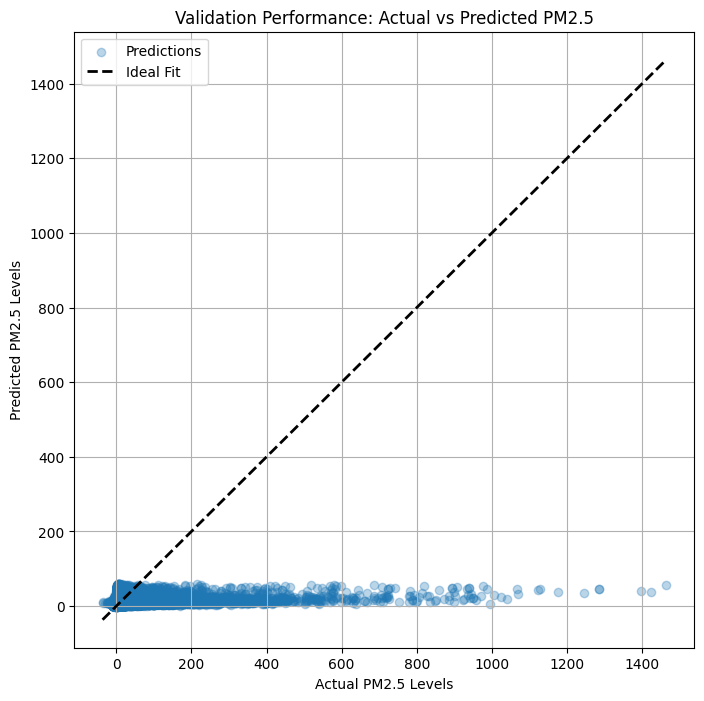

In [13]:
plt.figure(figsize=(8, 8))

# Scatter plot of actual vs predicted
plt.scatter(y_true_actual, y_pred_actual, alpha=0.3, label='Predictions')

min_val = min(y_true_actual.min(), y_pred_actual.min())
max_val = max(y_true_actual.max(), y_pred_actual.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Fit')

plt.xlabel('Actual PM2.5 Levels')
plt.ylabel('Predicted PM2.5 Levels')
plt.title('Validation Performance: Actual vs Predicted PM2.5')
plt.legend()
plt.grid(True)
plt.show()

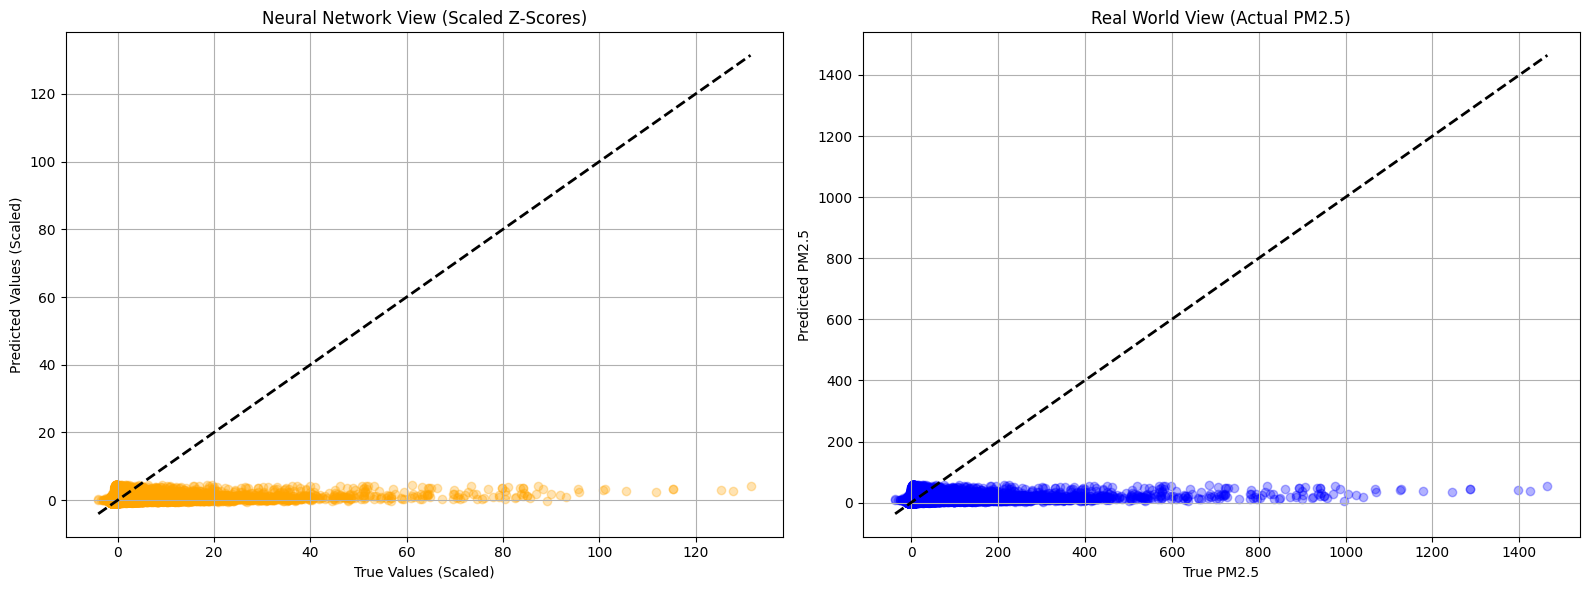

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Scaled Data ---
axes[0].scatter(y_true_scaled, y_pred_scaled, alpha=0.3, color='orange')
axes[0].plot([y_true_scaled.min(), y_true_scaled.max()], 
             [y_true_scaled.min(), y_true_scaled.max()], 'k--', lw=2)
axes[0].set_title('Neural Network View (Scaled Z-Scores)')
axes[0].set_xlabel('True Values (Scaled)')
axes[0].set_ylabel('Predicted Values (Scaled)')
axes[0].grid(True)

# --- Actual Data ---
axes[1].scatter(y_true_actual, y_pred_actual, alpha=0.3, color='blue')
axes[1].plot([y_true_actual.min(), y_true_actual.max()], 
             [y_true_actual.min(), y_true_actual.max()], 'k--', lw=2)
axes[1].set_title('Real World View (Actual PM2.5)')
axes[1].set_xlabel('True PM2.5')
axes[1].set_ylabel('Predicted PM2.5')
axes[1].grid(True)

plt.tight_layout()
plt.show()